In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np # Needed for np.mean
import re # Needed for sort_key regex
import itertools # Needed for itertools.cycle
import os # Needed for os.makedirs and os.path.join
from typing import Dict, List, Any, Optional, Literal

In [2]:
def plot_hi_het_triangle(
    all_generations_data: Dict[str, List[Dict[str, Any]]],
    plot_mode: Literal['individuals', 'highlight_selected', 'means'] = 'individuals',
    highlight_gen: Optional[str] = None,
    show_individual_points_behind_means: bool = False,
    save_filename: Optional[str] = None
):
    """
    My aim with this function is to plot Hybrid Index (HI) versus Heterozygosity (HET)
    for my simulated generations, offering various display options to suit my analysis needs.

    Args:
        all_generations_data (dict): This is the dictionary holding all my simulation data.
                                     Keys are generation names (e.g., 'Ancestry_1', 'F2', 'BC1A'),
                                     and values are lists of dictionaries, each containing
                                     'HI' and 'HET' values for individual organisms within that generation.
        plot_mode (Literal): This parameter lets me choose what I want to plot:
            - 'individuals': My default choice. I'll plot all individual points for every generation
                             with distinct colours and interactive hover functionality.
            - 'highlight_selected': I'll plot individual points, making one specific generation
                                    stand out in colour while all others appear in grayscale.
                                    This mode needs the 'highlight_gen' parameter to be set.
            - 'means': I'll display only the mean HI and HET values for each generation,
                       along with their labels. I can also choose to show the individual
                       points in a light background for context if I wish.
        highlight_gen (str, optional): If I've chosen 'highlight_selected' mode, this is the name
                                       of the generation I want to highlight (e.g., 'F4', 'BC1A').
                                       It's ignored in other modes.
        show_individual_points_behind_means (bool): When 'means' mode is active, setting this
                                                    to True will plot all individual points
                                                    in a very light grayscale behind the mean points.
                                                    My default for this is False.
        save_filename (str, optional): If I provide a filename here, I'll save the generated plot.
                                       Otherwise, it will just be displayed.
    """
    # First, I'm setting up my plot figure and axes. I've chosen a good size for clarity.
    fig, ax = plt.subplots(figsize=(10, 8))

    # I'm removing the top and right spines to give my plot a cleaner, less cluttered look.
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # I'm making the remaining spines a bit thicker to give them more prominence.
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)

    # I'm labelling my axes clearly so anyone looking at the plot understands what they're seeing.
    ax.set_xlabel("Hybrid Index (proportion of the selected allele)", fontsize=12)
    ax.set_ylabel("Heterozygosity (proportion heterozygous loci)", fontsize=12)

    # Common Helper Functions and Data Structures

    # This is my sorting key function. It helps me arrange my generation labels
    # in a sensible order for consistent plotting and legend display.
    def sort_key(label: str):
        # I'm giving specific numerical priorities to my ancestor populations and F1.
        if label == 'Ancestry_1': return (0, label)
        if label == 'Ancestry_2': return (1, label)
        if label == 'F1': return (2, label)
        # For F generations, I'm extracting the number to sort them numerically.
        match_f = re.match(r'F(\d+)', label)
        if match_f:
            return (3, int(match_f.group(1)))
        # A fallback for any F labels not matching the standard pattern.
        elif label.startswith('F'):
            return (3, float('inf'), label) # Placing non-standard Fs at the end of F-group.
        # For BC (Backcross) generations, I'm doing something similar,
        # extracting the number and handling the 'A' or 'B' suffix.
        match_bc = re.match(r'BC(\d+)([A-Z]?)', label)
        if match_bc:
            num_part = int(match_bc.group(1))
            suffix_part = match_bc.group(2) if match_bc.group(2) else ''
            return (4, num_part, suffix_part)
        # A fallback for any BC labels not matching the standard pattern.
        elif label.startswith('BC'):
            return (4, float('inf'), label) # Placing non-standard BCs at the end of BC-group.
        # Any other labels will go at the very end.
        return (5, label)

    # I'm getting all my generation names and sorting them using my custom key.
    sorted_gen_names = sorted(list(all_generations_data.keys()), key=sort_key)

    # I'm setting up a cycle of default colours. This ensures I have a good variety
    # for all the generations when no specific highlighting is in play.
    default_colors_cycle = itertools.cycle([
        'blue', 'red', 'green', 'purple', 'orange', 'brown', 'pink', 'teal',
        'darkviolet', 'magenta', 'cyan', 'lime', 'gold', 'navy', 'maroon',
        'darkgreen', 'darkred', 'darkblue', 'darkgoldenrod', 'darkslategray',
        'cornflowerblue', 'olivedrab', 'peru', 'rosybrown', 'salmon',
        'seagreen', 'sienna', 'darkkhaki', 'mediumorchid', 'lightcoral'
    ])
    # This dictionary will store the assigned colour for each generation
    # so that it remains consistent throughout the plotting.
    color_map = {}

    # This helper function determines the colour for a given generation.
    # It prioritises specific colours for Ancestry_1, Ancestry_2, and F1, then uses the cycle.
    def get_color_for_mode(gen_name):
        if gen_name not in color_map:
            if gen_name == 'Ancestry_1': color_map[gen_name] = 'black'
            elif gen_name == 'Ancestry_2': color_map[gen_name] = 'grey'
            elif gen_name == 'F1': color_map[gen_name] = 'purple'
            else: color_map[gen_name] = next(default_colors_cycle)
        return color_map[gen_name]

    # I'm preparing an empty list to hold the elements for my plot legend.
    legend_elements = []

    # Conditional Plotting Logic based on `plot_mode`

    if plot_mode == 'individuals' or plot_mode == 'highlight_selected':
        # These modes require individual point plotting and potentially hover functionality.
        scatter_artists = [] # I'll store the matplotlib scatter objects here for hover.
        scatter_data_map = {} # This will link scatter objects to their data for hover.

        # I'm looping through each sorted generation to plot its individuals.
        for gen_name in sorted_gen_names:
            values = all_generations_data.get(gen_name, [])
            if not values: continue # If there's no data for this generation, I'll skip it.

            # I'm extracting Hybrid Index and Heterozygosity values, ensuring they're not None.
            # Using 'H' instead of 'HET' as per the corrected data loading/saving.
            hi_values = [d['HI'] for d in values if 'HI' in d and d['HI'] is not None]
            het_values = [d['HET'] for d in values if 'HET' in d and d['HET'] is not None] # Expecting 'H' key now

            if hi_values and het_values: # Only plot if I have valid data for both HI and HET.
                point_data_for_current_gen = []
                # I'm preparing the data structure needed for the hover functionality.
                for i in range(len(hi_values)):
                    point_data_for_current_gen.append({'gen_name': gen_name, 'hi': hi_values[i], 'het': het_values[i]})

                # Determine style based on plot_mode
                if plot_mode == 'highlight_selected':
                    HIGHLIGHT_COLOR = 'dodgerblue'
                    HIGHLIGHT_ALPHA = 1.0
                    HIGHLIGHT_MARKER_SIZE = 35
                    GRAYSCALE_COLOR = 'silver'
                    GRAYSCALE_ALPHA = 0.2
                    GRAYSCALE_MARKER_SIZE = 20

                    if gen_name == highlight_gen:
                        color = HIGHLIGHT_COLOR
                        alpha = HIGHLIGHT_ALPHA
                        s = HIGHLIGHT_MARKER_SIZE
                        zorder = 5 # Bring highlighted to front
                    else:
                        color = GRAYSCALE_COLOR
                        alpha = GRAYSCALE_ALPHA
                        s = GRAYSCALE_MARKER_SIZE
                        zorder = 2 # Other generations in background
                else: # 'individuals' mode
                    color = get_color_for_mode(gen_name)
                    alpha = 0.7
                    s = 20
                    zorder = 2

                # Now, I'm plotting the individual points.
                sc = ax.scatter(hi_values, het_values,
                                color=color,
                                alpha=alpha,
                                marker='o',
                                s=s,
                                zorder=zorder)
                scatter_artists.append(sc)
                scatter_data_map[sc] = point_data_for_current_gen

                # I'm adding an entry for this generation to my legend.
                if gen_name not in [el.get_label() for el in legend_elements]: # Prevent duplicate legend entries in highlight mode
                    legend_elements.append(plt.Line2D([0], [0], marker='o', color='w',
                                                    markerfacecolor=color, markersize=8,
                                                    alpha=alpha, label=gen_name))
            else:
                print(f"I'm skipping plotting for {gen_name} as I found no valid HI/Het data.")

    elif plot_mode == 'means':
        # My objective here is to plot only the mean HI and HET for each generation.
        # I have an option to show individual points subtly in the background.
        ax.set_xlabel("Mean Hybrid Index (proportion A alleles)", fontsize=12) # Adapting label for clarity
        ax.set_ylabel("Mean Heterozygosity (proportion heterozygous loci)", fontsize=12) # Adapting label for clarity

        if show_individual_points_behind_means:
            # If I've chosen to show background points, I'll plot them first.
            for gen_name in sorted_gen_names:
                values = all_generations_data.get(gen_name, [])
                if not values: continue # Skipping if no data.

                hi_values = [d['HI'] for d in values if 'HI' in d and d['HI'] is not None]
                het_values = [d['HET'] for d in values if 'HET' in d and d['HET'] is not None] # Expecting 'H' key now

                if hi_values and het_values:
                    # I'm using a very light grey and low alpha to make them subtle.
                    ax.scatter(hi_values, het_values, color='lightgray', alpha=0.1, s=10, zorder=1)
                else:
                    print(f"I'm skipping individual background points for {gen_name} due to missing data.")

        # Now, I'm going through each generation to plot its mean.
        for gen_name in sorted_gen_names:
            values = all_generations_data.get(gen_name, [])
            if not values: # If a generation has no data, I'll report it and skip.
                print(f"I'm skipping mean plot for {gen_name} due to missing data.")
                continue

            hi_values = [d['HI'] for d in values if 'HI' in d and d['HI'] is not None]
            het_values = [d['HET'] for d in values if 'HET' in d and d['HET'] is not None] # Expecting 'HET' key now

            # I'll only calculate and plot means if I have valid HI and HET data.
            if hi_values and het_values:
                mean_hi = np.mean(hi_values) # Calculating the mean Hybrid Index.
                mean_het = np.mean(het_values) # Calculating the mean Heterozygosity.

                color = get_color_for_mode(gen_name) # Getting the consistent colour for this generation.

                # I'm setting a larger marker size for the mean points to make them stand out.
                marker_size = 80
                if gen_name in ['Ancestry_1', 'Ancestry_2', 'F1']: # Making anchor points slightly larger still.
                    marker_size = 100

                # I'm plotting the mean point, adding a black edge for definition.
                ax.scatter(mean_hi, mean_het, color=color, s=marker_size, marker='o', edgecolors='black', linewidth=1.5, zorder=3)

                # I'm adding a text label right next to the mean point for easy identification.
                ax.text(mean_hi + 0.01, mean_het + 0.01, gen_name, fontsize=9, color=color, ha='left', va='bottom', zorder=4)

                # I'm adding this generation to the legend, making sure I don't add duplicates.
                if gen_name not in [el.get_label() for el in legend_elements]:
                    legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=8, label=gen_name))
            else:
                print(f"I'm skipping mean plot for {gen_name} as I found no valid HI/HET data to calculate mean.")
    else:
        # If an invalid plot mode is provided, I'll inform the user and close the figure.
        print(f"Error: Invalid plot_mode '{plot_mode}'. It must be 'individuals', 'highlight_selected', or 'means'.")
        plt.close(fig)
        return

    # Common Plot Elements

    # I'm drawing the defining triangle edges on the plot. These represent the boundaries
    # of the possible HI/HET space for a two-ancestor cross.
    triangle_edges = [
        [(0.0, 0.0), (0.5, 1.0)], # Edge from Ancestry_1 corner to F1 apex
        [(0.5, 1.0), (1.0, 0.0)], # Edge from F1 apex to Ancestry_2 corner
        [(0.0, 0.0), (1.0, 0.0)]  # Base edge between Ancestry_1 and Ancestry_2
    ]
    for (x0, y0), (x1, y1) in triangle_edges:
        # I'm plotting each edge as a grey line, placing them at the very back (zorder=0).
        ax.plot([x0, x1], [y0, y1], linestyle='-', color='gray', linewidth=1.5, alpha=0.7, zorder=0)

    # I'm setting the limits for my X and Y axes to slightly extend beyond 0 and 1,
    # ensuring all my points and labels are fully visible.
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    # I'm ensuring the aspect ratio is equal so the triangle doesn't get distorted.
    ax.set_aspect('equal', adjustable='box')

    # I'm adjusting the subplot layout to make room for the legend on the right.
    plt.subplots_adjust(left=0.1, right=0.75, top=0.9, bottom=0.1)

    # I'm adding the legend to my plot, positioning it outside the main plot area
    # for better clarity and making sure it doesn't have a visible frame.
    ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.35, 1), fontsize=10, frameon=False)

    # If I've provided a filename, I'll save the plot before displaying it.
    if save_filename:
        plt.savefig(save_filename, bbox_inches='tight') # 'tight' ensures everything fits.
        print(f"Plot saved to {save_filename}")

    # Finally, I'm displaying my plot.
    plt.show()

In [10]:
csv_filename = r"C://Users//sophi//Jupyter_projects//Hybrid_Code//output_data//dataframes//triangle_plot_flat.csv" # Define the name of your flattened CSV file
reconstructed_all_generations_data = {} # Initialise an empty dictionary to store the data

print(f"Attempting to load and prepare data from '{csv_filename}'")

try:
    # 1. Load the flattened CSV into a pandas DataFrame
    loaded_df = pd.read_csv(csv_filename)
    print("CSV loaded successfully into DataFrame.")
    # You can uncomment the line below to inspect the loaded DataFrame if needed
    print("DataFrame head:\n", loaded_df.head())

    # 2. Check if the 'generation' column exists, which is crucial for grouping
    if 'generation' not in loaded_df.columns:
        print(f"Error: 'generation' column not found in '{csv_filename}'. Cannot group data for plotting.")
        # If this happens, your CSV is structured differently than expected.
        # You might need to adjust the CSV creation process.
    else:
        # Define the columns that your `plot_hi_het_triangle` function expects
        # for each individual (HI and H for heterozygosity)
        individual_keys_for_plot = ['id', 'HI', 'HET'] # Assuming 'HET' is the key for Heterozygosity

        # Group the DataFrame by the 'generation' column and reconstruct the
        # `Dict[str, List[Dict[str, Any]]]` format
        for gen_name, gen_df in loaded_df.groupby('generation'):
            # Filter the group DataFrame to only include the necessary columns
            # This makes sure the individual dictionaries passed to the plot function
            # only contain relevant data and don't include extra columns if any.
            actual_cols_for_individual_dicts = [col for col in individual_keys_for_plot if col in gen_df.columns]

            # Convert each group's DataFrame to a list of dictionaries,
            # where each dictionary represents an individual
            reconstructed_all_generations_data[str(gen_name)] = gen_df[actual_cols_for_individual_dicts].to_dict(orient='records')

        print(f"Data successfully reconstructed for {len(reconstructed_all_generations_data)} generations.")
        # Optional: Print an example to verify
        if 'F1' in reconstructed_all_generations_data and reconstructed_all_generations_data['F1']:
            print(f"Example of reconstructed 'F1' data (first individual): {reconstructed_all_generations_data['F1'][0]}")
        else:
            print("No 'F1' generation found or it is empty in the reconstructed data.")

except FileNotFoundError:
    print(f"Error: The file '{csv_filename}' was not found. Please ensure it's in the same directory as this script, or provide the full path.")
    reconstructed_all_generations_data = {} # Ensure it's empty if file not found, to prevent errors
except Exception as e:
    print(f"An unexpected error occurred during data loading or reconstruction: {e}")
    reconstructed_all_generations_data = {} # Ensure it's empty on other errors

Attempting to load and prepare data from 'C://Users//sophi//Jupyter_projects//Hybrid_Code//output_data//dataframes//triangle_plot_flat.csv'
CSV loaded successfully into DataFrame.
DataFrame head:
    generation  id   HI  HET
0  Ancestry_1   1  1.0  0.0
1  Ancestry_1   2  1.0  0.0
2  Ancestry_1   3  1.0  0.0
3  Ancestry_1   4  1.0  0.0
4  Ancestry_1   5  1.0  0.0
Data successfully reconstructed for 32 generations.
Example of reconstructed 'F1' data (first individual): {'id': 101, 'HI': 0.5, 'HET': 1.0}


In [11]:
# Now, I'm defining the base directory where I want to save my plot images.
plot_output_dir = r'C:\Users\sophi\Jupyter_projects\Hybrid_Code\output_data\triangle_plot_images'

# I'm making sure this output directory exists. If it doesn't, I'll create it.
os.makedirs(plot_output_dir, exist_ok=True)

Plot saved to C:\Users\sophi\Jupyter_projects\Hybrid_Code\output_data\triangle_plot_images\means_test.png


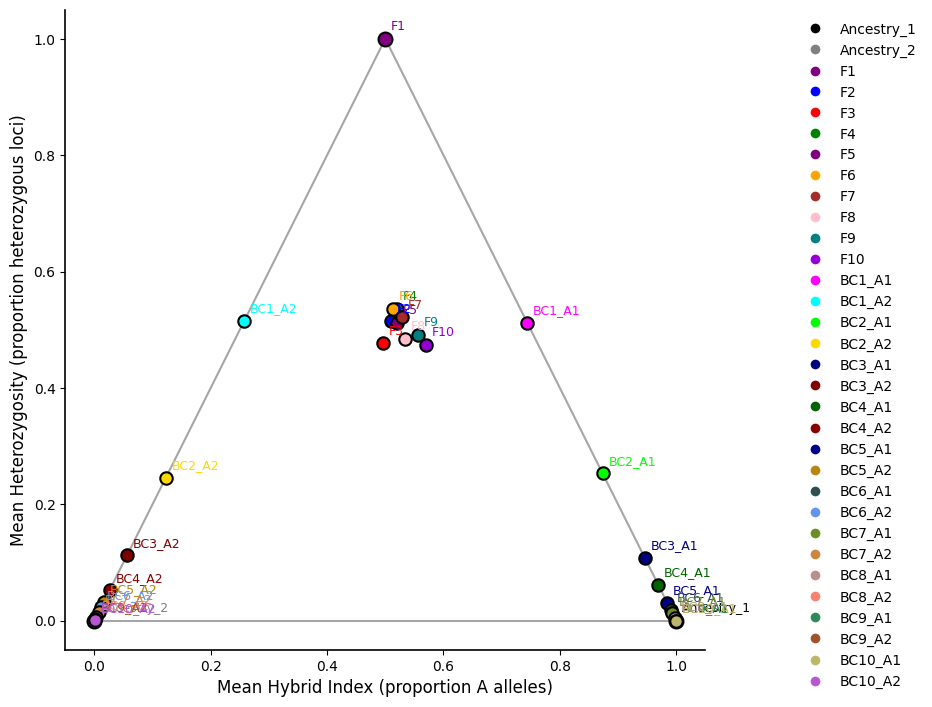

Plotting complete! All individual points plot saved to: C:\Users\sophi\Jupyter_projects\Hybrid_Code\output_data\triangle_plot_images\all_presentation.png


In [12]:
# Check if data was successfully loaded before attempting to plot
if reconstructed_all_generations_data:
    plot_hi_het_triangle(
        all_generations_data=reconstructed_all_generations_data, # Using the data loaded from CSV
        plot_mode='means',
        save_filename=os.path.join(plot_output_dir, 'means_test.png')
    )
    print(f"Plotting complete! All individual points plot saved to: {os.path.join(plot_output_dir, 'all_presentation.png')}")
else:
    print("Skipping plot generation because no valid data was loaded.")